# BÀI TẬP: TITANIC
**Nguồn:** kaggle.com/c/titanic (891 dòng)


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
# TODO
print(f'Số dòng: {len(df)} | Số cột: {len(df.columns)}')
df.info()



Số dòng: 891 | Số cột: 15
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## A.2. Missing values & Duplicate data

In [14]:
# TODO
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else 'Không có cột nào thiếu dữ liệu')
print()
print("Duplicate rows (toàn bộ):", df.duplicated().sum())

age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Duplicate rows (toàn bộ): 107


## A.3. Invalid values

In [4]:
# TODO
print('Số lượng người có tuổi <= 0:', (df['age'] <= 0).sum())

print("Số lượng vé có giá < 0:", (df['fare'] < 0).sum())

print("Số người đi cùng là SibSp < 0:", (df['sibsp'] < 0).sum())

print("Số người đi cùng là Parch < 0:", (df['parch'] < 0).sum())

invalid_child = ((df['who'] == 'child') & (df['adult_male'] == True)).sum()
print("Trẻ em nhưng adult_male=True:", invalid_child)

invalid_alone = ((df['alone'] == True) & ((df['sibsp'] > 0) | (df['parch'] > 0))).sum()
print("Báo là đi một mình nhưng có người thân đi cùng:", invalid_alone)




Số lượng người có tuổi <= 0: 0
Số lượng vé có giá < 0: 0
Số người đi cùng là SibSp < 0: 0
Số người đi cùng là Parch < 0: 0
Trẻ em nhưng adult_male=True: 0
Báo là đi một mình nhưng có người thân đi cùng: 0


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [5]:
# TODO
df['family_size'] = df['sibsp'] + df['parch'] + 1
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [6]:
# TODO
for col in ['age', 'fare']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")

print()
print("Mode sex:", df['sex'].mode()[0])
print("Mode class:", df['class'].mode()[0])
print("Mode embark_town:", df['embark_town'].mode()[0])

age: Mean=29.70, Median=28.00, Mode=24.00
fare: Mean=32.20, Median=14.45, Mode=8.05

Mode sex: male
Mode class: Third
Mode embark_town: Southampton


## Group 2 — Dispersion

In [7]:
# TODO
for col in ['age', 'fare']:
    s = df[col]
    range_ = s.max() - s.min()
    std_ = s.std()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    cv = std_ / s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- age ---
Range=79.58, Std=14.53, IQR=17.88, CV=0.49
--- fare ---
Range=512.33, Std=49.69, IQR=23.09, CV=1.54


## Group 3 — Location and Shape

--- age ---
P25=20.12, P50=28.00, P75=38.00
Skewness=0.39, Kurtosis=0.17
--- fare ---
P25=7.91, P50=14.45, P75=31.00
Skewness=4.78, Kurtosis=33.20


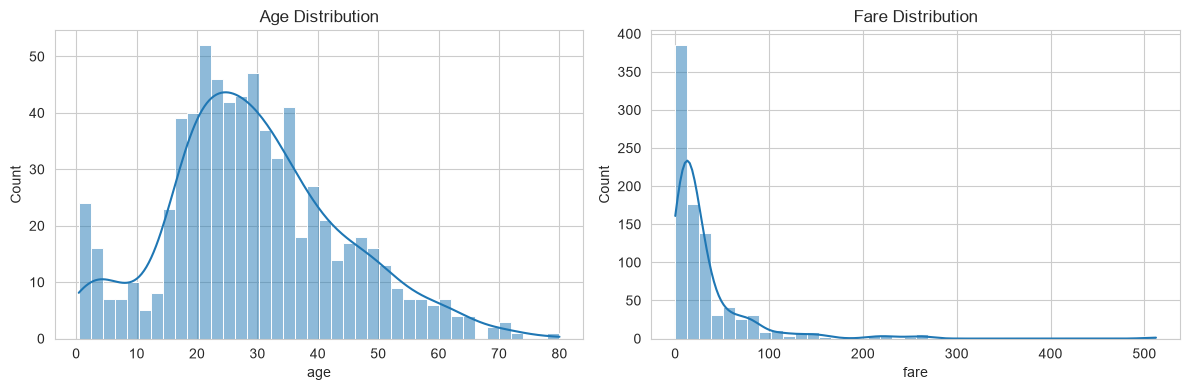

In [8]:
# TODO
for col in ['age', 'fare']:
    s = df[col].dropna()
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'].dropna(), bins=40, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')

sns.histplot(df['fare'].dropna(), bins=40, kde=True, ax=axes[1])
axes[1].set_title('Fare Distribution')

plt.tight_layout()
plt.show()

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [9]:
# TODO
pclass_survived = df.groupby('pclass')['survived'].mean()

max_rate = pclass_survived.max()
min_rate = pclass_survived.min()
diff = max_rate - min_rate

print(pclass_survived)
print(f"\n-> Hạng vé có tỷ lệ sống sót cao nhất: Hạng {pclass_survived.idxmax()} ({max_rate*100:.2f}%)")
print(f"-> Hạng vé có tỷ lệ sống sót thấp nhất: Hạng {pclass_survived.idxmin()} ({min_rate*100:.2f}%)")
print(f"-> Mức chênh lệch: {diff*100:.2f}% (khoảng {diff:.2f} lần)")

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

-> Hạng vé có tỷ lệ sống sót cao nhất: Hạng 1 (62.96%)
-> Hạng vé có tỷ lệ sống sót thấp nhất: Hạng 3 (24.24%)
-> Mức chênh lệch: 38.73% (khoảng 0.39 lần)


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [10]:
# TODO
sex_survived = df.groupby('sex')['survived'].mean()
print("--- Tỷ lệ sống sót theo Giới tính ---")
print(sex_survived)
sex_diff = sex_survived['female'] - sex_survived['male']
print(f"Chênh lệch Giới tính: {sex_diff*100:.2f}%\n")

pclass_survived = df.groupby('pclass')['survived'].mean()
print("--- Tỷ lệ sống sót theo Hạng vé ---")
print(pclass_survived)
pclass_diff = pclass_survived.max() - pclass_survived.min()
print(f"Chênh lệch Hạng vé: {pclass_diff*100:.2f}%\n")

pivot = df.pivot_table(index='sex', columns='pclass', values='survived', aggfunc='mean')
print("--- Kết hợp Giới tính & Hạng vé ---")
print(pivot)
print('\nVới giới tính là nữ khi ở hạng vé là 3 thì tỉ lệ sống sót là 50% so với giới tính là nam ở hạng vé 1 nhưng tỉ lệ sống sót chỉ có 36,9%')
print('Vậy giới tính ảnh hưởng đến mạng sống mạnh hơn hạng vé')

--- Tỷ lệ sống sót theo Giới tính ---
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
Chênh lệch Giới tính: 55.31%

--- Tỷ lệ sống sót theo Hạng vé ---
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64
Chênh lệch Hạng vé: 38.73%

--- Kết hợp Giới tính & Hạng vé ---
pclass         1         2         3
sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447

Với giới tính là nữ khi ở hạng vé là 3 thì tỉ lệ sống sót là 50% so với giới tính là nam ở hạng vé 1 nhưng tỉ lệ sống sót chỉ có 36,9%
Vậy giới tính ảnh hưởng đến mạng sống mạnh hơn hạng vé


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [11]:
# TODO
fare_stats = df.groupby('survived')['fare'].agg(['mean', 'median', 'count'])
fare_stats.index = ['Tử vong (0)', 'Sống sót (1)']
print("--- Thống kê giá vé theo trạng thái sống sót ---")
print(fare_stats)

print("\n" + "="*40 + "\n")

df['fare_group'] = pd.qcut(df['fare'], q=4, labels=['Rất rẻ (Q1)', 'Trung bình (Q2)', 'Đắt (Q3)', 'Rất đắt (Q4)'])

fare_survived = df.groupby('fare_group', observed=False)['survived'].agg(['count', 'mean'])
fare_survived['mean'] = fare_survived['mean'] * 100
fare_survived.columns = ['Số lượng hành khách', 'Tỷ lệ sống sót (%)']
print("--- Tỷ lệ sống sót theo nhóm giá vé ---")
print(fare_survived)

print('Có, vé càng đắt tiền thì khả năng sống sót càng cao')

--- Thống kê giá vé theo trạng thái sống sót ---
                   mean  median  count
Tử vong (0)   22.117887    10.5    549
Sống sót (1)  48.395408    26.0    342


--- Tỷ lệ sống sót theo nhóm giá vé ---
                 Số lượng hành khách  Tỷ lệ sống sót (%)
fare_group                                              
Rất rẻ (Q1)                      223           19.730942
Trung bình (Q2)                  224           30.357143
Đắt (Q3)                         222           45.495495
Rất đắt (Q4)                     222           58.108108
Có, vé càng đắt tiền thì khả năng sống sót càng cao


## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [12]:
# TODO
def group_family(size):
    if size == 1:
        return '1. Đi một mình (1)'
    elif 2 <= size <= 4:
        return '2. Gia đình nhỏ (2-4)'
    else:
        return '3. Gia đình đông (>=5)'

df['family_group'] = df['family_size'].apply(group_family)

family_stats = df.groupby('family_group')['survived'].agg(
    So_luong='count',
    Ty_le_song_sot=lambda x: f"{x.mean()*100:.2f}%"
)
print("--- Tỷ lệ sống sót theo Quy mô gia đình ---")
print(family_stats)

print('Gia đình đông có ảnh hưởng đến tỉ lệ sống sót(nhóm >= 5 người)')

--- Tỷ lệ sống sót theo Quy mô gia đình ---
                        So_luong Ty_le_song_sot
family_group                                   
1. Đi một mình (1)           537         30.35%
2. Gia đình nhỏ (2-4)        292         57.88%
3. Gia đình đông (>=5)        62         16.13%
Gia đình đông có ảnh hưởng đến tỉ lệ sống sót(nhóm >= 5 người)


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [13]:
# TODO
embark_stats = df.groupby('embark_town')['survived'].agg(
    So_hanh_khach='count',
    So_nguoi_song_sot='sum',
    Ty_le_song_sot=lambda x: f"{x.mean()*100:.2f}%"
).reset_index()

print("--- Tỷ lệ sống sót theo Cảng lên tàu (embark_town) ---")
print(embark_stats)

print("\n" + "="*50 + "\n")

print('Cảng lên tàu Cherbourg có tỉ lệ sống sót cao nhất')

--- Tỷ lệ sống sót theo Cảng lên tàu (embark_town) ---
   embark_town  So_hanh_khach  So_nguoi_song_sot Ty_le_song_sot
0    Cherbourg            168                 93         55.36%
1   Queenstown             77                 30         38.96%
2  Southampton            644                217         33.70%


Cảng lên tàu Cherbourg có tỉ lệ sống sót cao nhất


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

1. Giới tính là yếu tố quyết định hàng đầu: Phụ nữ có tỷ lệ sống sót áp đảo (74.2%) so với nam giới (18.9%) nhờ quy tắc ưu tiên "Phụ nữ và trẻ em trước".
2. Bất bình đẳng theo địa vị kinh tế: Hành khách Hạng 1 (hoặc mua vé đắt tiền) có cơ hội sống sót cao gấp hơn 2.5 lần Hạng 3 (63% so với 24%) do ở boong tàu phía trên và gần xuồng cứu sinh hơn.
3. Gia đình nhỏ có lợi thế nhất: Nhóm đi gia đình từ 2–4 người đạt tỷ lệ sống sót cao nhất (58%), trong khi đi một mình (30%) hay gia đình quá đông >= 5 người (16%) đều có tỷ lệ sống sót rất thấp.
4. Cảng Cherbourg có tỷ lệ sống cao do yếu tố khách hàng: Cảng Cherbourg dẫn đầu về tỷ lệ sống sót (55%) chủ yếu vì đây là nơi tập trung phần lớn hành khách giàu có mua vé Hạng 1.